<img src="https://media.giphy.com/media/FSzLVme5Y3n3LMOiqP/giphy.gif" width="250" height="250"/>


Remember the rules of ~Fight~ Code Club:
1. ALWAYS DOCUMENT
2. Cite resources that you use (paste links)
3. Include the names people who you worked with
4. Be neat and organized

## Questions

With your own data that you collected:
1. Create 2 graphs between two variables. Be sure to include the title, labels of both axis. Include a legend if necessary. Be sure that nothing overlaps in the graph (words or legends, etc). 

2. Write 1-2 sentences that describe the main information presented and a conclusion that you could draw from that graph. 

3. Display the graphs side by side in one figure. 

4. Do a third graph that is not a line graph or bar chart (with proper labels and titles). Make sure this third graph displays different information than presented in step 1.


# Pull ACS 2022 tract level data from Census API Massachusets, cleaned the data, made new columns, and grabbed the country name from the long NAME field.

In [48]:
import requests
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

CENSUS_KEY = "449daedeb4203d7011951c788e288009b73360d8"

# the ACS variables needed and I used for my further research
variables = [
    "B25064_001E",  # median rent
    "B19013_001E",  # median household income
    "B25001_001E",  # total housing units
    "B25024_004E",  # units in 2-unit buildings
    "B25024_005E",  # units in 3-4 unit buildings
    "B25024_006E",  # units in 5-9 unit buildings
    "B25024_007E",  # units in 10-19 unit buildings
    "B25024_008E",  # units in 20+ unit buildings
]

url = "https://api.census.gov/data/2022/acs/acs5"
params = {
    "get": f"NAME,{','.join(variables)}",
    "for": "tract:*",
    "in":  "state:25",  # 25 = Massachusetts
    "key": CENSUS_KEY
}

response = requests.get(url, params=params)
raw = response.json()
df = pd.DataFrame(raw[1:], columns=raw[0])

# rename columns so they make sense
df = df.rename(columns={
    "B25064_001E": "median_rent",
    "B19013_001E": "median_income",
    "B25001_001E": "total_units",
    "B25024_004E": "units_2",
    "B25024_005E": "units_3_4",
    "B25024_006E": "units_5_9",
    "B25024_007E": "units_10_19",
    "B25024_008E": "units_20plus",
})

# converting to Numbers
num_cols = ["median_rent", "median_income", "total_units",
            "units_2", "units_3_4", "units_5_9", "units_10_19", "units_20plus"]
for col in num_cols:
    df[col] = pd.to_numeric(df[col], errors="coerce")
df[num_cols] = df[num_cols].replace(-666666666, np.nan)

# build density share variables
df["gentle_density_units"] = df["units_2"] + df["units_3_4"]
df["high_density_units"]   = df["units_5_9"] + df["units_10_19"] + df["units_20plus"]
df["gentle_density_share"] = df["gentle_density_units"] / df["total_units"].replace(0, np.nan)
df["high_density_share"]   = df["high_density_units"]   / df["total_units"].replace(0, np.nan)

# log of rent 
df["log_rent"]   = np.log(df["median_rent"].replace(0, np.nan))
df["log_income"] = np.log(df["median_income"].replace(0, np.nan))

# use county from the NAME column for the box plot later
df["county"] = df["NAME"].str.extract(r', (.+?) County')[0]

print(f"Loaded {len(df):,} census tracts")
df[["median_rent", "log_rent", "gentle_density_share", "high_density_share"]].head()




Loaded 1,620 census tracts


,median_rent,log_rent,gentle_density_share,high_density_share
0,1106.0,7.008505,0.362283,0.161264
1,1289.0,7.161622,0.038667,0.001234
2,NaN,NaN,0.014497,0.016237
3,NaN,NaN,0.018058,0.000000
4,1683.0,7.428333,0.050607,0.000000


# Graph Explained - first one generated is the scatter plot of log income vs log rent and graph 2 is the line chart where im comparing gentle density share vs high density share across income bins

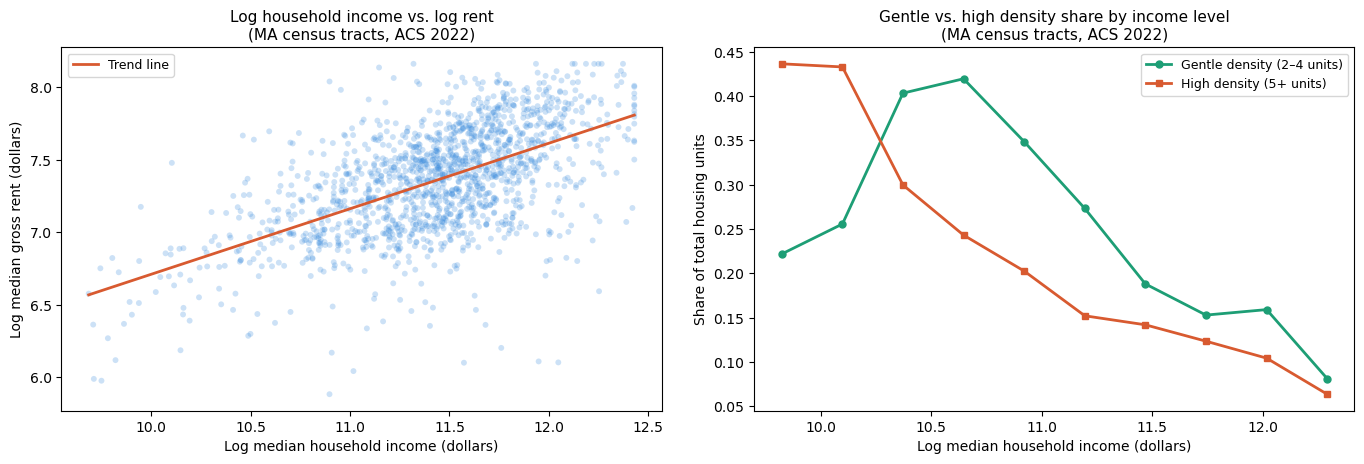

In [49]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

#  Graph 1: scatter plot  
clean = df.dropna(subset=["log_income", "log_rent"])

ax1.scatter(
    clean["log_income"], clean["log_rent"],
    alpha=0.25, s=18, color="#378ADD", edgecolors="none"
)

# trend line
m, b = np.polyfit(clean["log_income"], clean["log_rent"], 1)
x_line = np.linspace(clean["log_income"].min(), clean["log_income"].max(), 100)
ax1.plot(x_line, m * x_line + b, color="#D85A30", linewidth=2, label="Trend line")

ax1.set_title("Log household income vs. log rent\n(MA census tracts, ACS 2022)", fontsize=11)
ax1.set_xlabel("Log median household income (dollars)", fontsize=10)
ax1.set_ylabel("Log median gross rent (dollars)", fontsize=10)
ax1.legend(fontsize=9)

# ── Graph 2
clean2 = df.dropna(subset=["log_income", "gentle_density_share", "high_density_share"])
clean2["income_bin"] = pd.cut(clean2["log_income"], bins=10)
binned = clean2.groupby("income_bin", observed=True)[["gentle_density_share", "high_density_share"]].mean()
binned["mid"] = binned.index.map(lambda x: x.mid)

ax2.plot(binned["mid"], binned["gentle_density_share"],
        marker="o", color="#1D9E75", linewidth=2, markersize=5, label="Gentle density (2–4 units)")
ax2.plot(binned["mid"], binned["high_density_share"],
        marker="s", color="#D85A30", linewidth=2, markersize=5, label="High density (5+ units)")

ax2.set_title("Gentle vs. high density share by income level\n(MA census tracts, ACS 2022)", fontsize=11)
ax2.set_xlabel("Log median household income (dollars)", fontsize=10)
ax2.set_ylabel("Share of total housing units", fontsize=10)
ax2.legend(fontsize=9, loc="upper right")

plt.tight_layout(pad=2.0)
plt.savefig("graphs_1_and_2.png", dpi=150)
plt.show()




# Graph 3> Histogram of mediam rents

In [37]:
print(df.columns)

Index(['NAME', 'median_rent', 'median_income', 'total_units', 'units_2',
       'units_3_4', 'units_5_9', 'units_10_19', 'units_20plus', 'state',
       'county', 'tract', 'gentle_density_units', 'high_density_units',
       'gentle_density_share', 'high_density_share', 'log_rent', 'log_income'],
      dtype='object')


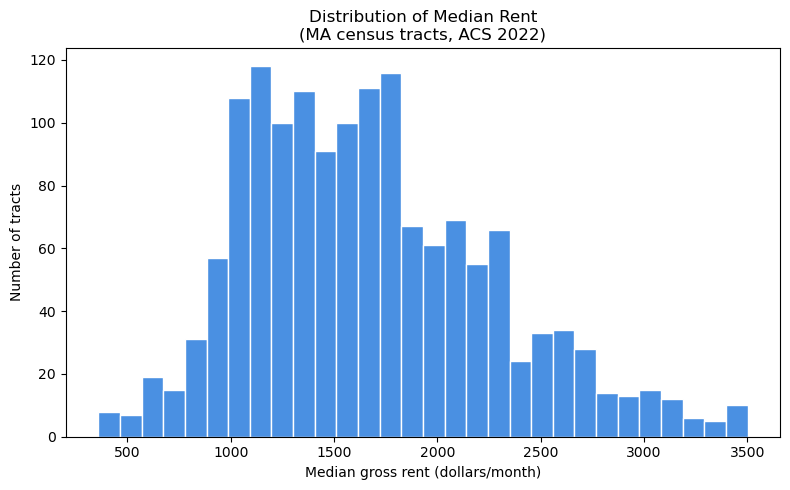

In [47]:
plt.figure(figsize=(8,5))
plt.hist(df["median_rent"].dropna(), bins=30, color="#4A90E2", edgecolor="white")

plt.title("Distribution of Median Rent\n(MA census tracts, ACS 2022)", fontsize=12)
plt.xlabel("Median gross rent (dollars/month)", fontsize=10)
plt.ylabel("Number of tracts", fontsize=10)

plt.tight_layout()
plt.show()


<Figure size 800x500 with 0 Axes>

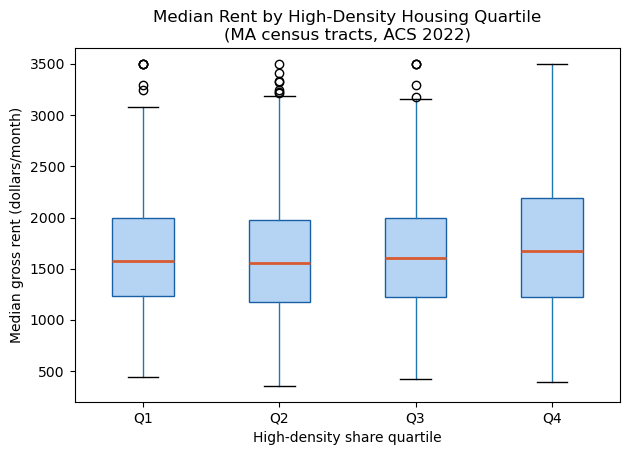

In [46]:
df["high_density_quartile"] = pd.qcut(df["high_density_share"], 4, labels=["Q1","Q2","Q3","Q4"])
plt.figure(figsize=(8,5))

df.boxplot(
    column="median_rent",
    by="high_density_quartile",
    grid=False,
    patch_artist=True,
    boxprops=dict(facecolor="#B5D4F4", color="#185FA5"),
    medianprops=dict(color="#D85A30", linewidth=2)
)

plt.title("Median Rent by High-Density Housing Quartile\n(MA census tracts, ACS 2022)", fontsize=12)
plt.suptitle("")  # removes default pandas title
plt.xlabel("High-density share quartile", fontsize=10)
plt.ylabel("Median gross rent (dollars/month)", fontsize=10)

plt.tight_layout()
plt.show()


# Summary
### All four graphs just show basic patterns in the ACS data. The first one shows that places with higher incomes usually have higher rents. The second one shows that high‑density housing becomes more common as income goes up, while gentle‑density barely changes. The histogram shows that most tracts fall in the middle of the rent range, with only a few very cheap or very expensive areas. The last boxplot shows that areas with more high‑density housing tend to have higher and more consistent rents. Overall, the graphs just show that income, density, and rent all move together in pretty expected ways.